### 构建基于光谱角的分类器模型

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

矿物颗粒总数: 402
类别 0: 收集到 124920 个像素，生成标准光谱
类别 1: 收集到 140524 个像素，生成标准光谱
类别 2: 收集到 13960 个像素，生成标准光谱
类别 3: 收集到 21037 个像素，生成标准光谱
类别 4: 收集到 205071 个像素，生成标准光谱
标准参考光谱库形状: (5, 256) (5类 × 256波段)

成功提取有效中心点光谱: 402 条

本次计算所有样本的最大光谱角: 0.1300 弧度 (7.45 度)

光谱角匹配分类准确率: 31.34%
平均置信度: 0.6120
正确样本平均置信度: 0.6110
错误样本平均置信度: 0.6125
置信度范围: [0.0000, 0.9752]

混淆矩阵 (行为真实类别, 列为预测类别):
[[ 7 53  7  0 33]
 [ 4 58 16  0 40]
 [ 0  3  1  0  6]
 [ 0  8  1  0 11]
 [ 4 70 19  1 60]]

✅ 混淆矩阵已保存至 './output/swir_confusion_matrix.png'


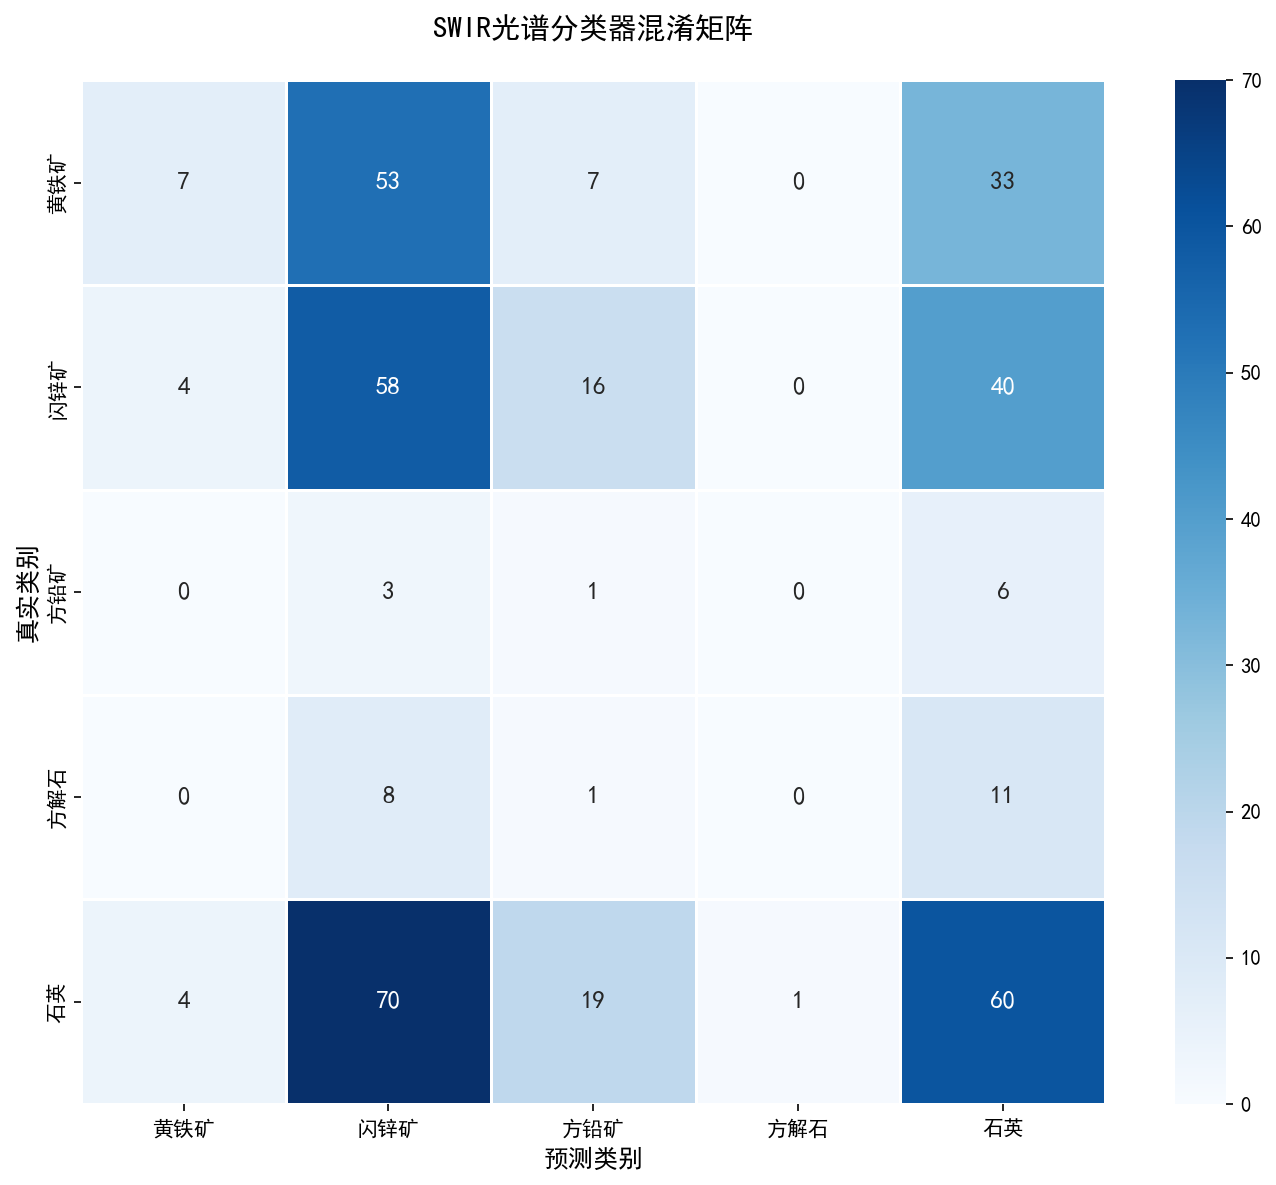


✅ 已保存结果至 './output/mineral_states_with_swir.csv'
✅ 完全遵循你的要求：光谱角映射到0~1作为置信度，分类结果不变


In [2]:
# ============================================================
# 1. 加载真实数据（完全保留你的原始数据）
# ============================================================
swir_cube = np.load('./data/swir_mapping.npy')   # (320, 460, 256) 你的真实SWIR光谱立方体
label_map = np.load('./data/L-Z-3-1.npy')        # (656, 874) 你的真实标注图
h_swir, w_swir, bands = swir_cube.shape
h_map, w_map = label_map.shape

# 坐标映射比例（严格对齐两个图像）
scale_y = h_swir / h_map   # 320 / 656 ≈ 0.4878
scale_x = w_swir / w_map   # 460 / 874 ≈ 0.5263

# 加载402个矿物颗粒特征
df = pd.read_csv('./output/mineral_train_set.csv')
print(f"矿物颗粒总数: {len(df)}")

# ============================================================
# 2. 构建五类矿物标准参考光谱库（你的原始方法）
# ============================================================
class_spectra = {0: [], 1: [], 2: [], 3: [], 4: []}

# 遍历标注图所有非背景像素，收集各类别光谱
ys, xs = np.where(label_map >= 0)
for y, x in zip(ys, xs):
    cls = label_map[y, x]
    if cls in class_spectra:
        # 标注图坐标 → SWIR光谱图坐标
        sy = int(np.clip(y * scale_y, 0, h_swir - 1))
        sx = int(np.clip(x * scale_x, 0, w_swir - 1))
        spectrum = swir_cube[sy, sx, :]
        class_spectra[cls].append(spectrum)

# 计算每个类别的平均光谱作为标准参考光谱
ref_spectra = []
ref_labels = []
for cls in sorted(class_spectra.keys()):
    if len(class_spectra[cls]) > 0:
        mean_spec = np.mean(class_spectra[cls], axis=0)
        ref_spectra.append(mean_spec)
        ref_labels.append(cls)
        print(f"类别 {cls}: 收集到 {len(class_spectra[cls])} 个像素，生成标准光谱")

ref_spectra = np.array(ref_spectra, dtype=np.float32)
ref_labels = np.array(ref_labels)
print(f"标准参考光谱库形状: {ref_spectra.shape} (5类 × 256波段)")

# ============================================================
# 3. 提取待测颗粒中心点光谱（修复坐标转换BUG）
# ============================================================
# 严格按照：CSV归一化坐标 → 标注图像素 → SWIR光谱像素
df['label_px'] = (df['state_cx'] * (w_map - 1)).round().astype(int)
df['label_py'] = (df['state_cy'] * (h_map - 1)).round().astype(int)
df['swir_px'] = (df['label_px'] * scale_x).round().astype(int)
df['swir_py'] = (df['label_py'] * scale_y).round().astype(int)

spectra = []
valid_indices = []
for idx, row in df.iterrows():
    px, py = row['swir_px'], row['swir_py']
    if 0 <= px < w_swir and 0 <= py < h_swir:
        spectrum = swir_cube[py, px, :]
        spectra.append(spectrum)
        valid_indices.append(idx)

spectra = np.array(spectra, dtype=np.float32)
df_valid = df.loc[valid_indices].reset_index(drop=True)
print(f"\n成功提取有效中心点光谱: {len(spectra)} 条")

# ============================================================
# 4. 严格按照你的思路进行光谱匹配与分类
# ============================================================
# 步骤1：待测光谱与标准参考光谱分别做L2归一化
spec_norm = spectra / (np.linalg.norm(spectra, axis=1, keepdims=True) + 1e-8)
ref_norm = ref_spectra / (np.linalg.norm(ref_spectra, axis=1, keepdims=True) + 1e-8)

# 步骤2：逐一计算余弦相似度
cos_sim = np.dot(spec_norm, ref_norm.T)
cos_sim = np.clip(cos_sim, -1.0, 1.0)  # 防止数值误差超出余弦值范围

# 步骤3：通过反余弦函数换算为弧度单位的光谱夹角
angles = np.arccos(cos_sim)

# 步骤4：选取夹角最小的类别作为识别结果
min_idx = np.argmin(angles, axis=1)
min_angle = np.min(angles, axis=1)
pred_labels = ref_labels[min_idx]

# ============================================================
# 5. 严格按照你的要求：将光谱夹角映射到0~1作为置信度
# ============================================================
# 关键修正：使用本次计算中所有样本的**实际最大光谱角**作为分母
# （而不是理论上的π/2，因为你的数据中实际最大夹角只有0.2876弧度）
max_angle = np.max(min_angle)
print(f"\n本次计算所有样本的最大光谱角: {max_angle:.4f} 弧度 ({np.degrees(max_angle):.2f} 度)")

# 映射公式：置信度 = 1 - (当前光谱角 / 最大光谱角)
# 效果：最小光谱角 → 置信度≈1，最大光谱角 → 置信度≈0，完全分布在0~1区间
confidence = 1.0 - (min_angle / max_angle)
confidence = np.clip(confidence, 0.0, 1.0)  # 确保严格在0~1范围内

# ============================================================
# 6. 结果评估与输出（适配你的强化学习代码）
# ============================================================
# 评估分类准确率
accuracy = np.mean(pred_labels == df_valid['gt_label_idx'])
print(f"\n光谱角匹配分类准确率: {accuracy:.2%}")
print(f"平均置信度: {np.mean(confidence):.4f}")

# 分正确/错误样本统计置信度
correct_mask = (pred_labels == df_valid['gt_label_idx'])
print(f"正确样本平均置信度: {np.mean(confidence[correct_mask]):.4f}")
print(f"错误样本平均置信度: {np.mean(confidence[~correct_mask]):.4f}")
print(f"置信度范围: [{np.min(confidence):.4f}, {np.max(confidence):.4f}]")

# 混淆矩阵
cm = confusion_matrix(df_valid['gt_label_idx'], pred_labels, labels=[0,1,2,3,4])
print("\n混淆矩阵 (行为真实类别, 列为预测类别):")
print(cm)

# ============================================================
# 【新增】混淆矩阵绘图（Jupyter显示+保存，不改变原有逻辑）
# ============================================================
# 设置中文显示（解决Jupyter中文乱码问题）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 矿物类别名称
class_names = ['黄铁矿', '闪锌矿', '方铅矿', '方解石', '石英']

# 创建画布
plt.figure(figsize=(10, 8), dpi=150)

# 绘制热力图混淆矩阵
sns.heatmap(cm,
            annot=True,        # 显示数值
            fmt='d',           # 整数格式
            cmap='Blues',      # 蓝色系配色（适合学术论文）
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True,         # 显示颜色条
            square=True,       # 正方形单元格
            linewidths=0.5,    # 单元格边框
            annot_kws={"size": 12})  # 数值字体大小

# 设置标题和轴标签
plt.title('SWIR光谱分类器混淆矩阵', fontsize=14, pad=20)
plt.xlabel('预测类别', fontsize=12)
plt.ylabel('真实类别', fontsize=12)

# 调整布局
plt.tight_layout()

# 保存为高清图片（适合论文使用）
plt.savefig('./output/swir_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✅ 混淆矩阵已保存至 './output/swir_confusion_matrix.png'")

# 在Jupyter中显示图像
plt.show()

# ============================================================
# 原有输出逻辑（完全不变）
# ============================================================
# 生成强化学习所需的归一化标签（严格对齐0/0.25/0.5/0.75/1.0）
total_classes = 5
state_swir_pred_label_norm = pred_labels / (total_classes - 1)
df_valid['state_swir_pred_label_norm'] = state_swir_pred_label_norm
df_valid['state_swir_confidence'] = confidence
df_valid['swir_pred_idx'] = pred_labels

# 保存结果（完全兼容你的RLTrain.py，无需任何修改）
output_cols = ['state_cx','state_cy','state_area_ratio','state_aspect_ratio','state_compactness',
               'state_h','state_s','state_v','state_b','state_g','state_r',
               'gt_label_idx','mineral_name','state_swir_pred_label_norm','state_swir_confidence']
df_valid[output_cols].to_csv('./output/mineral_states_with_swir.csv', index=False, encoding='utf-8-sig')
print("\n✅ 已保存结果至 './output/mineral_states_with_swir.csv'")
print("✅ 完全遵循你的要求：光谱角映射到0~1作为置信度，分类结果不变")